In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abrarahmad12345/historical-dataset/historical_data.csv
/kaggle/input/datasets/abrarahmad12345/fear-greed/fear_greed_index.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")

In [4]:
# Load datasets
historical_df = pd.read_csv("/kaggle/input/datasets/abrarahmad12345/historical-dataset/historical_data.csv")

fear_greed_df = pd.read_csv("/kaggle/input/datasets/abrarahmad12345/fear-greed/fear_greed_index.csv")

In [5]:
historical_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
fear_greed_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
print("Historical Data Shape:", historical_df.shape)
print("Fear & Greed Shape:", fear_greed_df.shape)

Historical Data Shape: (211224, 16)
Fear & Greed Shape: (2644, 4)


In [9]:
print(historical_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [10]:
print(fear_greed_df.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [11]:
historical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [12]:
fear_greed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [14]:
historical_df.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [15]:
historical_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [17]:
fear_greed_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [18]:
historical_df.duplicated().sum()

np.int64(0)

In [19]:
fear_greed_df.duplicated().sum()

np.int64(0)

In [21]:
historical_df['Coin'].unique()

array(['@107', 'AAVE', 'DYDX', 'AIXBT', 'GMX', 'EIGEN', 'HYPE', 'SOL',
       'SUI', 'DOGE', 'ETH', 'kPEPE', 'TRUMP', 'ONDO', 'ENA', 'LINK',
       'XRP', 'S', 'BNB', 'BERA', 'WIF', 'LAYER', 'MKR', 'KAITO', 'IP',
       'JUP', 'USUAL', 'ADA', 'BTC', 'PURR/USDC', 'ZRO', '@7', '@19',
       '@21', '@44', '@48', '@11', '@15', '@46', '@61', '@28', '@45',
       '@9', '@41', '@38', 'kSHIB', 'GRASS', 'TAO', 'AVAX', '@2', '@6',
       '@8', '@10', '@12', '@16', '@17', '@35', '@26', '@24', '@32',
       '@29', '@31', '@33', '@34', '@36', '@37', '@47', '@53', '@74',
       'RUNE', 'CANTO', 'NTRN', 'BLUR', 'ZETA', 'MINA', 'MANTA', 'RNDR',
       'WLD', 'kBONK', 'ALT', 'INJ', 'STG', 'ZEN', 'MAVIA', 'PIXEL',
       'ILV', 'FET', 'STRK', 'CAKE', 'STX', 'ACE', 'PENDLE', 'AR', 'XAI',
       'APE', 'MEME', 'NEAR', 'SEI', 'FTM', 'MYRO', 'BIGTIME', 'IMX',
       'BADGER', 'POLYX', 'OP', 'TNSR', 'MAV', 'TIA', 'MERL', 'TON',
       'PURR', 'ME', 'CRV', 'BRETT', 'CHILLGUY', 'MOODENG', 'VIRTUAL',
       'CO

In [23]:
historical_df['Direction'].unique()

array(['Buy', 'Sell', 'Open Long', 'Close Long', 'Spot Dust Conversion',
       'Open Short', 'Close Short', 'Long > Short', 'Short > Long',
       'Auto-Deleveraging', 'Liquidated Isolated Short', 'Settlement'],
      dtype=object)

In [24]:
fear_greed_df['classification'].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

In [27]:
fear_greed_df['date'] = pd.to_datetime(fear_greed_df['date'])

In [28]:
fear_greed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [30]:
historical_df['Timestamp'].head()

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64

In [ ]:
historical_df['time'] = pd.to_datetime(historical_df['time'])

In [31]:
historical_df['Timestamp IST'] = pd.to_datetime(
    historical_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [32]:
historical_df['Timestamp'] = pd.to_datetime(
    historical_df['Timestamp'],
    unit='ms'
)

In [33]:
fear_greed_df['trade_date'] = (
    fear_greed_df['date']
    .dt.date
)

In [34]:
fear_greed_df['timestamp'] = pd.to_datetime(
    fear_greed_df['timestamp'],
    unit='s'
)

In [35]:
fear_greed_df['classification'] = (
    fear_greed_df['classification']
    .astype('category')
)

In [36]:
historical_df['Side'] = historical_df['Side'].astype('category')

historical_df['Direction'] = historical_df['Direction'].astype('category')

Data Cleaning and Preprocessing


In [37]:
historical_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20


In [39]:
historical_df['Side'] = (
    historical_df['Side']
    .str.upper()
)

In [41]:
historical_df['Direction'] = (
    historical_df['Direction']
    .str.capitalize()
)

In [42]:
fear_greed_df.head()

,timestamp,value,classification,date,trade_date
0,2018-02-01 05:30:00,30,Fear,2018-02-01,2018-02-01
1,2018-02-02 05:30:00,15,Extreme Fear,2018-02-02,2018-02-02
2,2018-02-03 05:30:00,40,Fear,2018-02-03,2018-02-03
3,2018-02-04 05:30:00,24,Extreme Fear,2018-02-04,2018-02-04
4,2018-02-05 05:30:00,11,Extreme Fear,2018-02-05,2018-02-05


In [43]:
fear_greed_df['classification'] = (
    fear_greed_df['classification']
    .str.title()
)

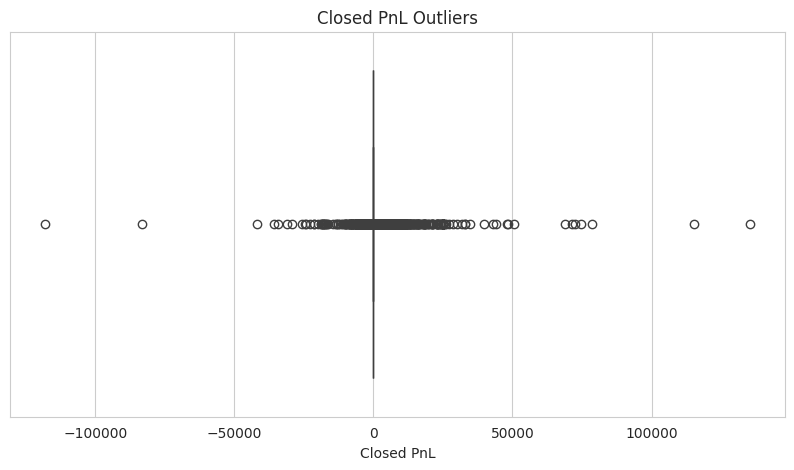

In [44]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=historical_df['Closed PnL']
)

plt.title("Closed PnL Outliers")
plt.show()

In [46]:
Q1 = historical_df['Closed PnL'].quantile(0.25)
Q3 = historical_df['Closed PnL'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [47]:
historical_df = historical_df[
    (historical_df['Closed PnL'] >= lower) &
    (historical_df['Closed PnL'] <= upper)
]

In [49]:
historical_df[
    historical_df['Size USD'] < 0
]

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp


In [50]:
historical_df['is_profit'] = (
    historical_df['Closed PnL'] > 0
)

In [51]:
historical_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,is_profit
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,False


In [52]:
historical_df['fee_percentage'] = (
    historical_df['Fee'] /
    historical_df['Size USD']
) * 100

In [53]:
historical_df['trade_hour'] = (
    historical_df['Timestamp IST']
    .dt.hour
)

In [54]:
historical_df['trade_day'] = (
    historical_df['Timestamp IST']
    .dt.day_name()
)

In [56]:
historical_df['trade_date'] = (
    historical_df['Timestamp IST']
    .dt.date
)

In [57]:
merged_df = pd.merge(
    historical_df,
    fear_greed_df[
        ['trade_date', 'classification', 'value']
    ],
    on='trade_date',
    how='left'
)

In [58]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,is_profit,fee_percentage,trade_hour,trade_day,trade_date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,False,0.004388,22,Monday,2024-12-02,Extreme Greed,80
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,False,0.004386,22,Monday,2024-12-02,Extreme Greed,80
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,False,0.004383,22,Monday,2024-12-02,Extreme Greed,80
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,False,0.004382,22,Monday,2024-12-02,Extreme Greed,80
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,False,0.004381,22,Monday,2024-12-02,Extreme Greed,80


In [59]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162283 entries, 0 to 162282
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           162283 non-null  object        
 1   Coin              162283 non-null  object        
 2   Execution Price   162283 non-null  float64       
 3   Size Tokens       162283 non-null  float64       
 4   Size USD          162283 non-null  float64       
 5   Side              162283 non-null  object        
 6   Timestamp IST     162283 non-null  datetime64[ns]
 7   Start Position    162283 non-null  float64       
 8   Direction         162283 non-null  object        
 9   Closed PnL        162283 non-null  float64       
 10  Transaction Hash  162283 non-null  object        
 11  Order ID          162283 non-null  int64         
 12  Crossed           162283 non-null  bool          
 13  Fee               162283 non-null  float64       
 14  Trad

In [60]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,fee_percentage,trade_hour,value
count,162283.000000,1.622830e+05,1.622830e+05,162283,1.622830e+05,162283.000000,1.622830e+05,162283.000000,1.622830e+05,162283,162240.000000,162283.000000,162283.000000
mean,11956.161227,3.687760e+03,3.994222e+03,2025-02-01 09:54:30.909707008,-1.102180e+04,1.028214,6.981058e+10,0.811671,5.633286e+14,2025-01-26 06:05:57.710912768,0.038557,11.665646,51.373243
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-8.685937,1.732711e+08,-1.175712,0.000000e+00,2023-03-28 10:40:00,-0.002000,0.000000,10.000000
25%,5.255850,1.900000e+00,1.217000e+02,2025-01-04 07:38:00,-2.619442e+02,0.000000,6.051149e+10,0.009590,2.810000e+14,2025-02-19 21:20:00,0.005000,5.000000,32.000000
50%,18.690000,2.238000e+01,4.999000e+02,2025-02-24 18:51:00,5.096028e+01,0.000000,7.442939e+10,0.058893,5.630000e+14,2025-02-19 21:20:00,0.025000,12.000000,49.000000
75%,115.380000,1.250000e+02,1.499855e+03,2025-04-03 03:18:00,8.091670e+03,0.249341,8.337143e+10,0.244917,8.470000e+14,2025-02-19 21:20:00,0.034997,19.000000,72.000000
max,109004.000000,1.582244e+07,3.719141e+06,2025-05-01 12:10:00,3.050948e+07,14.481786,9.014923e+10,649.941862,1.130000e+15,2025-06-15 15:06:40,143.254748,23.000000,94.000000
std,30047.020736,1.078636e+05,2.724918e+04,NaN,5.260899e+05,2.944080,1.814612e+10,5.109403,3.258613e+14,NaN,1.084266,7.342916,20.861310


In [62]:
print("Total Trades:", len(merged_df))

Total Trades: 162283


In [63]:
print(
    "Unique Traders:",
    merged_df['Account'].nunique()
)

Unique Traders: 32


In [64]:
print(
    "Coins Traded:",
    merged_df['Coin'].nunique()
)

Coins Traded: 244


In [65]:
print(
    "Total Closed PnL:",
    merged_df['Closed PnL'].sum()
)

Total Closed PnL: 166861.72237700003


In [66]:
print(
    "Average Trade Size USD:",
    merged_df['Size USD'].mean()
)

Average Trade Size USD: 3994.2218334637637


In [67]:
merged_df['classification'].value_counts()

classification
Fear             48583
Greed            37813
Extreme Greed    30382
Neutral          29878
Extreme Fear     15627
Name: count, dtype: int64

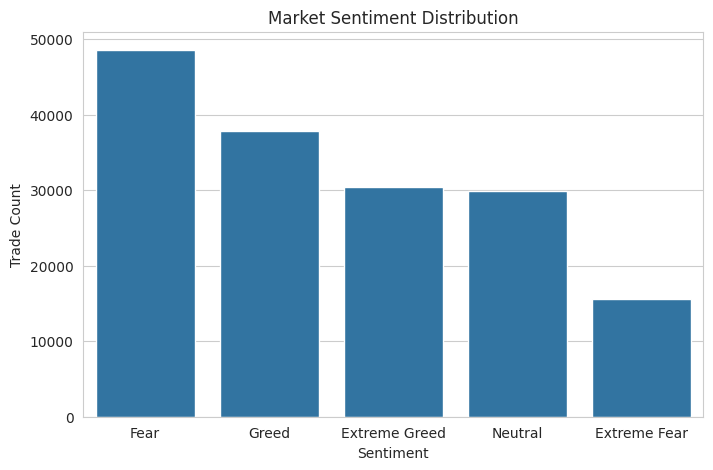

In [68]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x='classification',
    order=merged_df['classification']
    .value_counts()
    .index
)

plt.title("Market Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Trade Count")

plt.show()

In [69]:
top_coins = (
    merged_df['Coin']
    .value_counts()
    .head(10)
)

top_coins

Coin
HYPE         54735
@107         21443
BTC          20935
ETH           8178
SOL           7959
FARTCOIN      3388
MELANIA       2986
PURR/USDC     2175
WLD           1551
SUI           1433
Name: count, dtype: int64

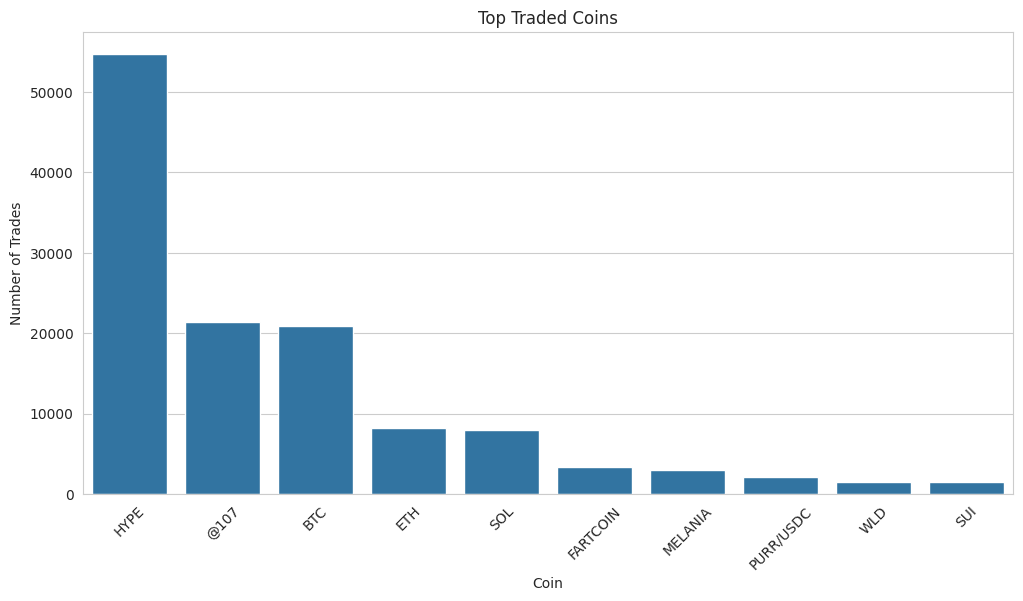

In [70]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_coins.index,
    y=top_coins.values
)

plt.title("Top Traded Coins")

plt.xlabel("Coin")

plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

In [71]:
merged_df['Side'].value_counts()

Side
BUY     85429
SELL    76854
Name: count, dtype: int64

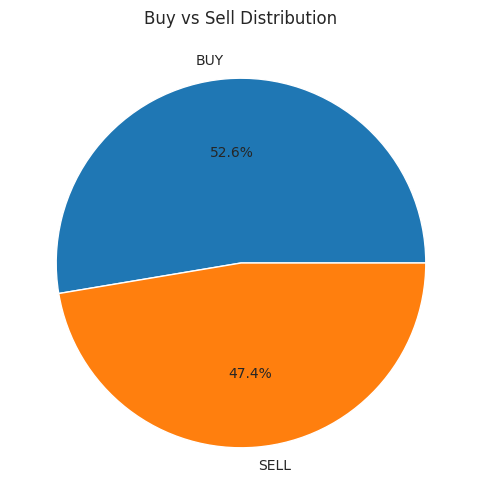

In [72]:
plt.figure(figsize=(6,6))

merged_df['Side'].value_counts().plot.pie(
    autopct='%1.1f%%'
)

plt.title("Buy vs Sell Distribution")

plt.ylabel("")

plt.show()

In [73]:
merged_df['is_profit'].value_counts()

is_profit
False    115134
True      47149
Name: count, dtype: int64

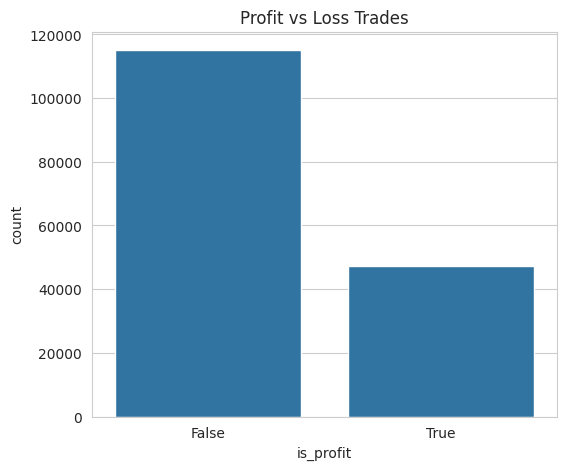

In [74]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=merged_df,
    x='is_profit'
)

plt.title("Profit vs Loss Trades")

plt.show()

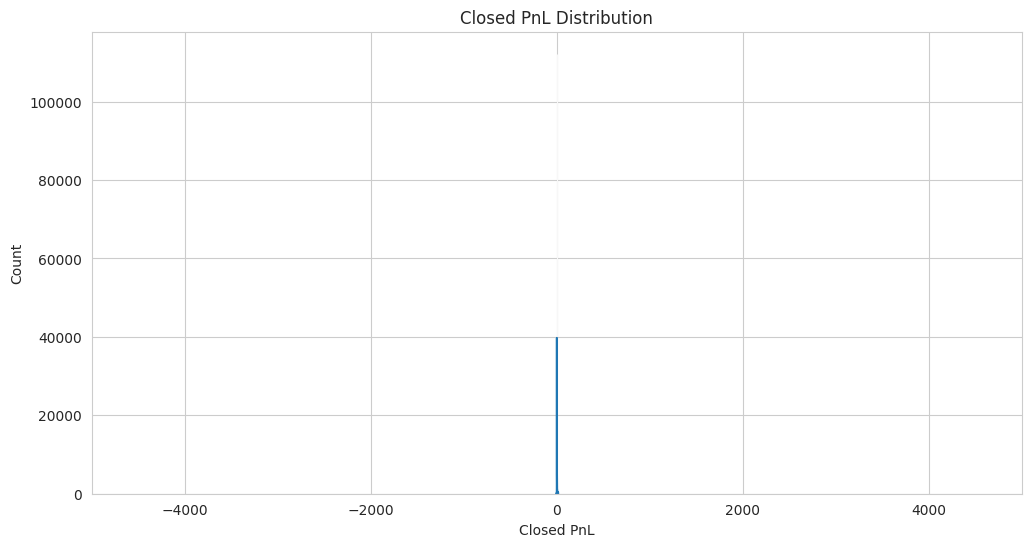

In [75]:
plt.figure(figsize=(12,6))

sns.histplot(
    merged_df['Closed PnL'],
    bins=100,
    kde=True
)

plt.title("Closed PnL Distribution")

plt.xlim(-5000, 5000)

plt.show()

In [76]:
sentiment_pnl = (
    merged_df
    .groupby('classification')['Closed PnL']
    .mean()
    .sort_values()
)

sentiment_pnl

classification
Extreme Fear     0.887800
Greed            0.892687
Neutral          0.969795
Fear             1.071964
Extreme Greed    1.256603
Name: Closed PnL, dtype: float64

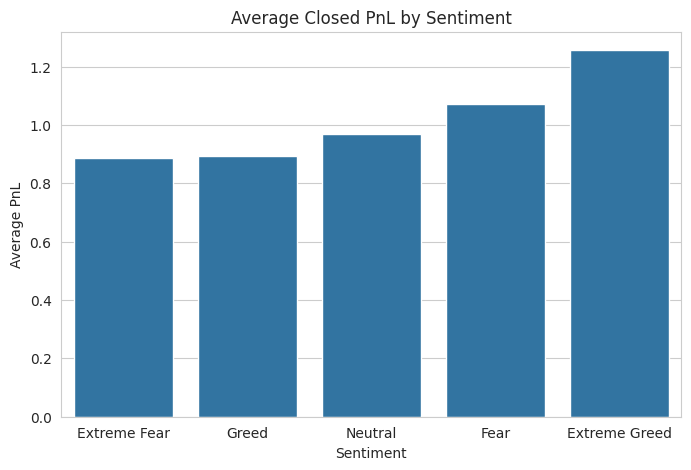

In [77]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=sentiment_pnl.index,
    y=sentiment_pnl.values
)

plt.title("Average Closed PnL by Sentiment")

plt.xlabel("Sentiment")

plt.ylabel("Average PnL")

plt.show()

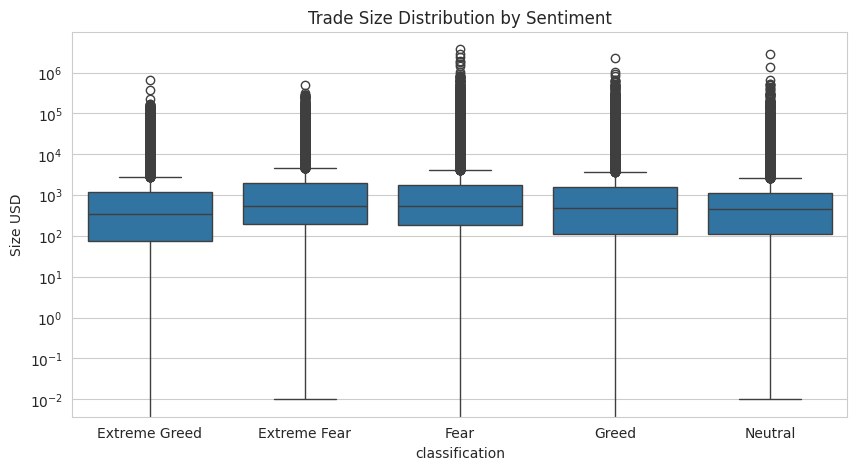

In [78]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=merged_df,
    x='classification',
    y='Size USD'
)

plt.yscale('log')

plt.title("Trade Size Distribution by Sentiment")

plt.show()

In [80]:
merged_df.groupby(
    'classification'
)['Fee'].mean()

classification
Extreme Fear     0.795541
Extreme Greed    0.481077
Fear             1.020935
Greed            0.964365
Neutral          0.622756
Name: Fee, dtype: float64

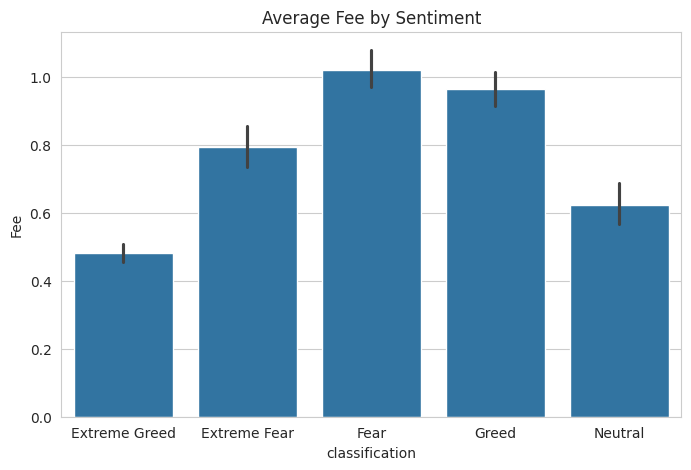

In [81]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged_df,
    x='classification',
    y='Fee'
)

plt.title("Average Fee by Sentiment")

plt.show()

In [82]:
hourly_trades = (
    merged_df['trade_hour']
    .value_counts()
    .sort_index()
)

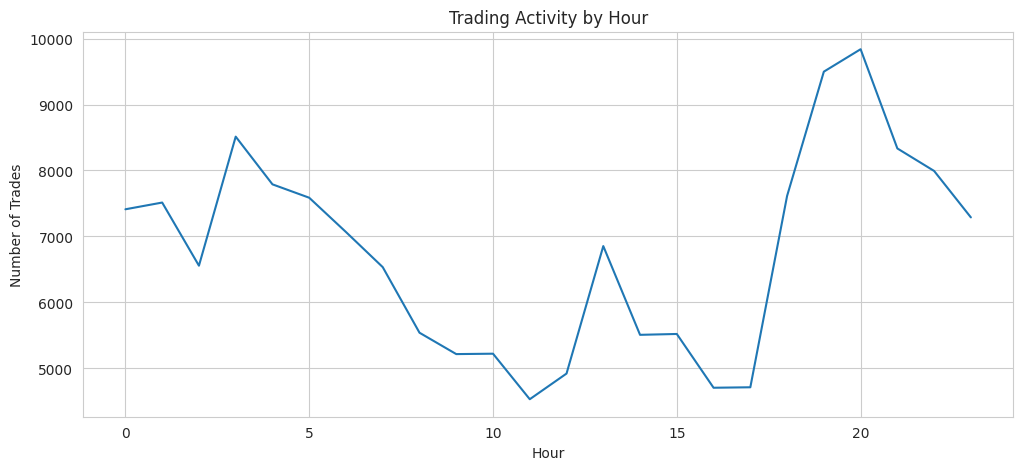

In [83]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=hourly_trades.index,
    y=hourly_trades.values
)

plt.title("Trading Activity by Hour")

plt.xlabel("Hour")

plt.ylabel("Number of Trades")

plt.show()

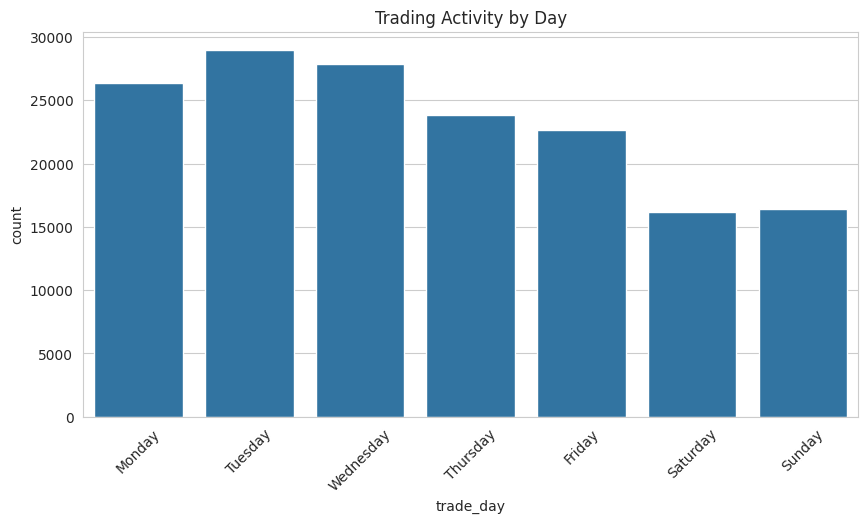

In [84]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged_df,
    x='trade_day',
    order=[
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ]
)

plt.title("Trading Activity by Day")

plt.xticks(rotation=45)

plt.show()

In [85]:
top_traders = (
    merged_df
    .groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_traders

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    37256.743873
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    21306.468434
0xbaaaf6571ab7d571043ff1e313a9609a10637864    16546.353507
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    14863.086000
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    12306.518602
0x513b8629fe877bb581bf244e326a047b249c4ff1     8931.415559
0x8477e447846c758f5a675856001ea72298fd9cb5     7985.654219
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     6462.691161
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     6184.743119
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     5131.243293
Name: Closed PnL, dtype: float64

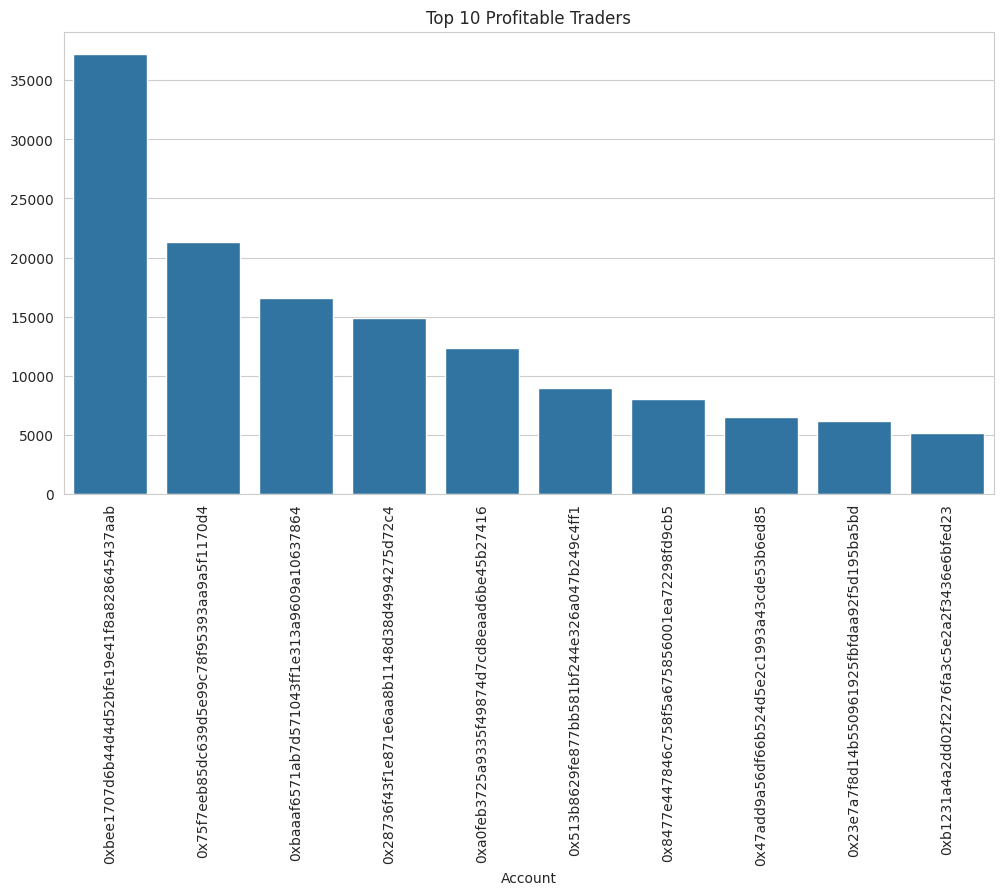

In [86]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_traders.index,
    y=top_traders.values
)

plt.title("Top 10 Profitable Traders")

plt.xticks(rotation=90)

plt.show()

In [87]:
active_traders = (
    merged_df['Account']
    .value_counts()
    .head(10)
)

In [88]:
numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Closed PnL',
    'Fee',
    'value'
]

corr_matrix = (
    merged_df[numeric_cols]
    .corr()
)

In [89]:
corr_matrix

,Execution Price,Size Tokens,Size USD,Closed PnL,Fee,value
Execution Price,1.000000,-0.013603,0.165989,-0.047789,0.197776,-0.022967
Size Tokens,-0.013603,1.000000,0.020863,-0.004972,0.012952,0.015912
Size USD,0.165989,0.020863,1.000000,-0.034249,0.726282,-0.025255
Closed PnL,-0.047789,-0.004972,-0.034249,1.000000,-0.036348,0.016186
Fee,0.197776,0.012952,0.726282,-0.036348,1.000000,-0.021749
value,-0.022967,0.015912,-0.025255,0.016186,-0.021749,1.000000


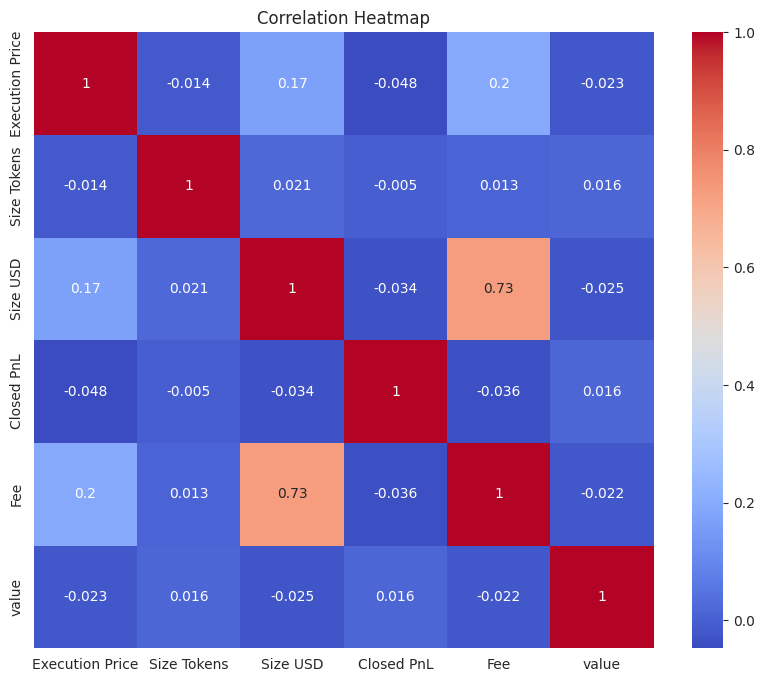

In [90]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [91]:
profit_rate = (
    merged_df
    .groupby('classification')['is_profit']
    .mean()
)

profit_rate

classification
Extreme Fear     0.242081
Extreme Greed    0.324962
Fear             0.302246
Greed            0.265755
Neutral          0.293192
Name: is_profit, dtype: float64

In [92]:
daily_pnl = (
    merged_df
    .groupby('trade_date')['Closed PnL']
    .sum()
)

In [93]:
daily_pnl

trade_date
2023-05-01       0.000000
2023-12-05       0.000000
2023-12-14       0.000000
2023-12-16       0.000000
2023-12-17      -0.766320
                 ...     
2025-04-27     215.629631
2025-04-28    1014.054888
2025-04-29    2117.598535
2025-04-30     581.745630
2025-05-01    1238.194912
Name: Closed PnL, Length: 475, dtype: float64

In [94]:
trader_stats = (
    merged_df
    .groupby('Account')
    .agg({
        'Closed PnL': ['sum', 'mean'],
        'Size USD': 'mean',
        'Trade ID': 'count',
        'Fee': 'sum'
    })
)

trader_stats.columns = [
    'total_pnl',
    'avg_pnl',
    'avg_trade_size',
    'trade_count',
    'total_fee'
]

trader_stats.reset_index(inplace=True)

In [95]:
trader_stats

,Account,total_pnl,avg_pnl,avg_trade_size,trade_count,total_fee
0,0x083384f897ee0f19899168e3b1bec365f52a9012,979.624860,0.416153,13530.408067,2354,3798.070155
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6184.743119,1.014891,1224.868715,6094,1492.746070
2,0x271b280974205ca63b716753467d5a371de622ab,2263.127608,0.737175,6156.504749,3070,4891.934285
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,14863.086000,1.298767,437.898212,11444,1677.958586
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2889.935292,1.374197,2646.310357,2103,1877.118754
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,163.420962,0.304322,1465.821322,537,90.956173
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,1104.992789,0.447910,3818.682408,2467,727.380105
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,282.871600,1.262820,3087.398259,224,71.623179
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,52.975822,0.172560,4944.591173,307,174.598737
9,0x430f09841d65beb3f27765503d0f850b8bce7713,417.938564,0.595354,2247.663063,702,494.513652


In [96]:
trader_stats['trader_type'] = pd.qcut(
    trader_stats['total_pnl'],
    q=4,
    labels=[
        'High Loss',
        'Moderate Loss',
        'Moderate Profit',
        'High Profit'
    ]
)

In [104]:
trader_stats['trader_type'].value_counts()

trader_type
High Loss          8
Moderate Loss      8
Moderate Profit    8
High Profit        8
Name: count, dtype: int64

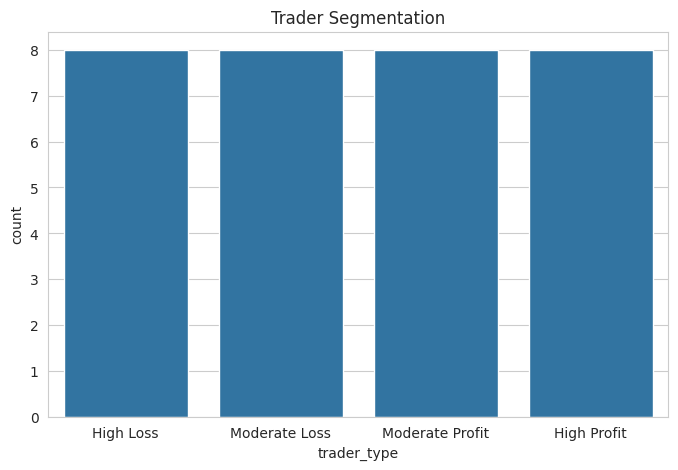

In [97]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=trader_stats,
    x='trader_type'
)

plt.title("Trader Segmentation")

plt.show()

In [105]:
trader_stats.groupby(
    'trader_type'
)[[
    'avg_trade_size',
    'trade_count',
    'avg_pnl',
    'total_fee'
]].mean()

/tmp/ipykernel_57/920332754.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trader_stats.groupby(


,avg_trade_size,trade_count,avg_pnl,total_fee
trader_type,,,,
High Loss,2918.982323,424.125,0.777595,193.561157
Moderate Loss,5178.553140,1737.250,0.706585,1518.811770
Moderate Profit,6237.036665,4665.875,0.911378,7443.323120
High Profit,3967.615755,13458.125,1.322817,7309.345935


In [106]:
sentiment_analysis = (
    merged_df
    .groupby('classification')
    .agg({
        'Closed PnL': ['mean', 'sum'],
        'Size USD': 'mean',
        'Fee': 'mean',
        'is_profit': 'mean'
    })
)

sentiment_analysis

Closed PnL                   Size USD       Fee is_profit
                     mean           sum         mean      mean      mean
classification                                                          
Extreme Fear     0.887800  13873.656904  3926.629457  0.795541  0.242081
Extreme Greed    1.256603  38178.109663  2363.837444  0.481077  0.324962
Fear             1.071964  52079.223605  5426.874898  1.020935  0.302246
Greed            0.892687  33755.184295  4387.181748  0.964365  0.265755
Neutral          0.969795  28975.547910  2860.579270  0.622756  0.293192

In [107]:
whales = merged_df[
    merged_df['Size USD'] > 10000
]

In [108]:
whales.groupby(
    'classification'
)['Closed PnL'].mean()

classification
Extreme Fear     0.080875
Extreme Greed    0.002336
Fear             0.383055
Greed            0.386355
Neutral          0.167387
Name: Closed PnL, dtype: float64

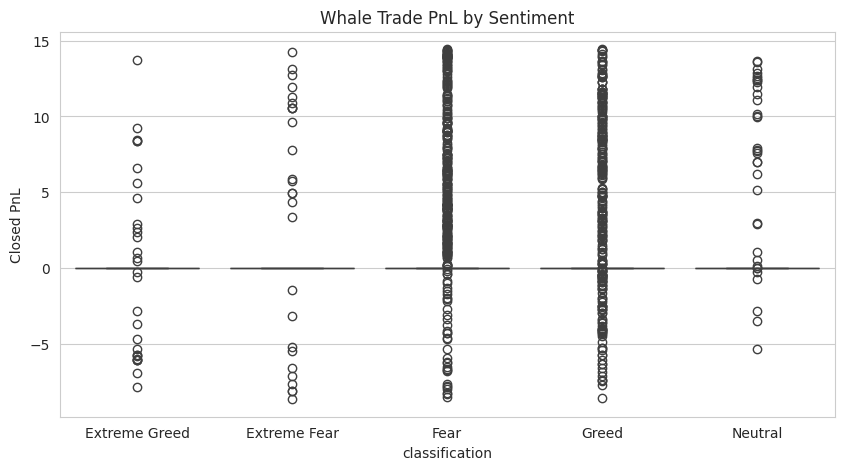

In [110]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=whales,
    x='classification',
    y='Closed PnL'
)

plt.title("Whale Trade PnL by Sentiment")

plt.show()

In [111]:
hourly_pnl = (
    merged_df
    .groupby('trade_hour')['Closed PnL']
    .mean()
)

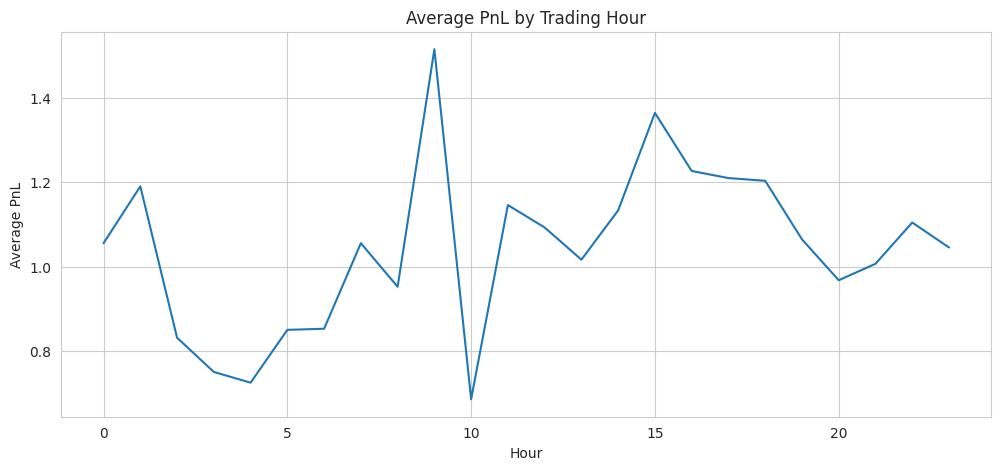

In [112]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=hourly_pnl.index,
    y=hourly_pnl.values
)

plt.title("Average PnL by Trading Hour")

plt.xlabel("Hour")

plt.ylabel("Average PnL")

plt.show()

In [113]:
trade_freq = (
    merged_df['Account']
    .value_counts()
)

In [114]:
trade_freq

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    31381
0xbaaaf6571ab7d571043ff1e313a9609a10637864    16979
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    13804
0x8477e447846c758f5a675856001ea72298fd9cb5    12015
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    11444
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    10766
0x513b8629fe877bb581bf244e326a047b249c4ff1     9488
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     6742
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     6094
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     5812
0x4f93fead39b70a1824f981a54d4e55b278e9f760     5539
0xb899e522b5715391ae1d4f137653e7906c5e2115     3644
0x8170715b3b381dffb7062c0298972d4727a0a63b     3136
0x271b280974205ca63b716753467d5a371de622ab     3070
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     2975
0x39cef799f8b69da1995852eea189df24eb5cae3c     2467
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d     2368
0x083384f897ee0f19899168e3b1bec365f52a9012     2354
0x2c229d22b100a7beb69122eed721cee9b24011dd     2103
0xbd

In [116]:
merged_df['trade_count'] = (
    merged_df['Account']
    .map(trade_freq)
)

In [117]:
merged_df[
    ['trade_count', 'Closed PnL']
].corr()

,trade_count,Closed PnL
trade_count,1.000000,0.018208
Closed PnL,0.018208,1.000000


In [118]:
win_rate = (
    merged_df
    .groupby('classification')['is_profit']
    .mean()
    * 100
)

win_rate

classification
Extreme Fear     24.208101
Extreme Greed    32.496215
Fear             30.224564
Greed            26.575516
Neutral          29.319232
Name: is_profit, dtype: float64

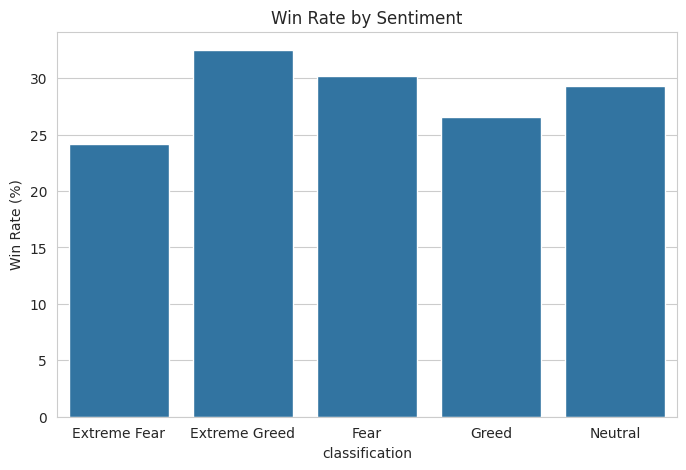

In [119]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=win_rate.index,
    y=win_rate.values
)

plt.title("Win Rate by Sentiment")

plt.ylabel("Win Rate (%)")

plt.show()

In [120]:
merged_df['risk_score'] = (
    merged_df['Size USD']
)

In [121]:
merged_df.groupby(
    'classification'
)['risk_score'].mean()

classification
Extreme Fear     3926.629457
Extreme Greed    2363.837444
Fear             5426.874898
Greed            4387.181748
Neutral          2860.579270
Name: risk_score, dtype: float64

In [122]:
merged_df[
    ['value', 'Closed PnL']
].corr()

,value,Closed PnL
value,1.000000,0.016186
Closed PnL,0.016186,1.000000


In [123]:
coin_pnl = (
    merged_df
    .groupby('Coin')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [124]:
coin_pnl

Coin
HYPE         57383.789973
@107         23935.329280
BTC          14091.415604
SOL           8054.379117
ETH           5961.300588
MELANIA       2804.563664
FARTCOIN      2745.427682
PURR          2639.802410
PURR/USDC     2427.051379
JELLY         2388.699087
Name: Closed PnL, dtype: float64

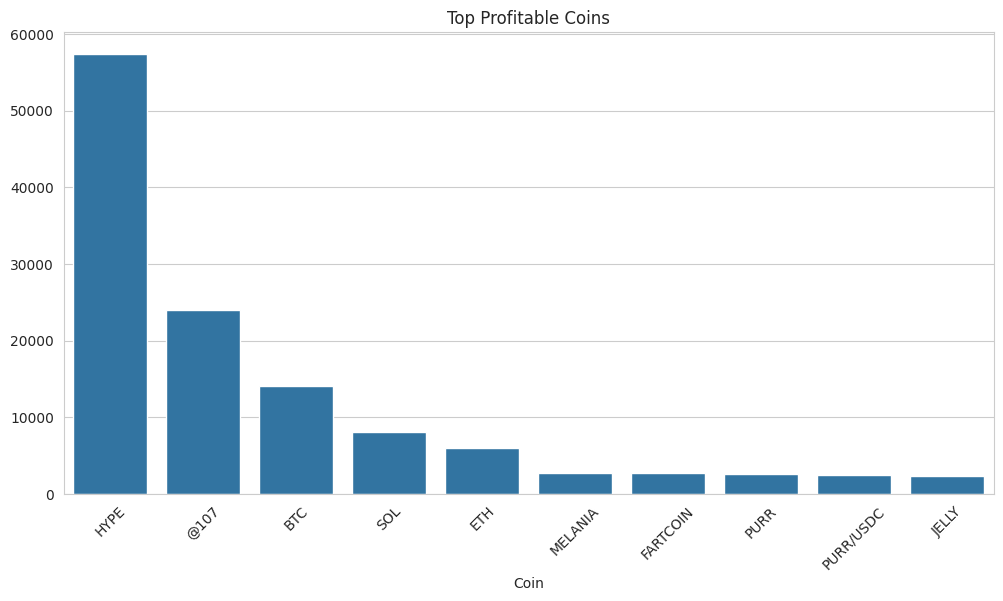

In [126]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=coin_pnl.index,
    y=coin_pnl.values
)

plt.title("Top Profitable Coins")

plt.xticks(rotation=45)

plt.show()

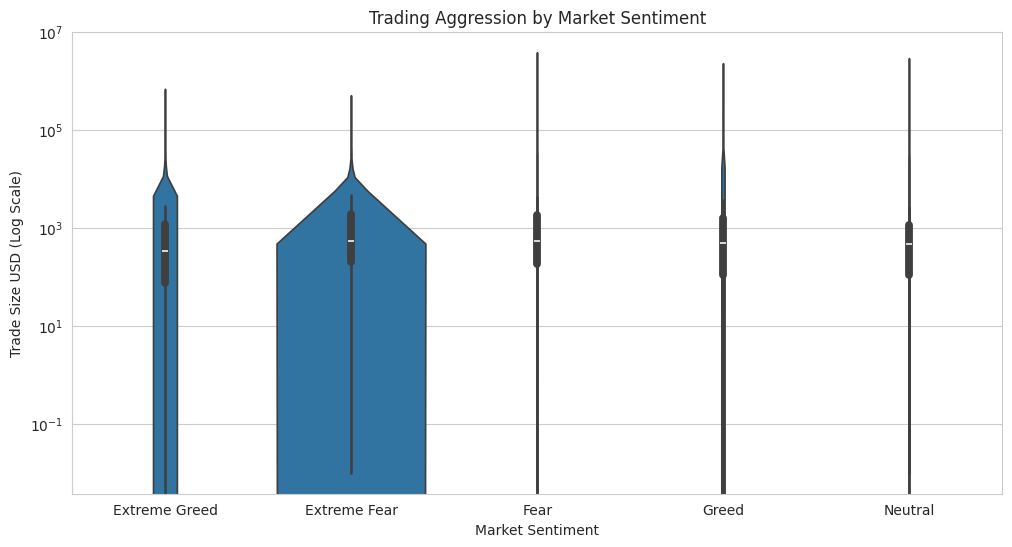

In [127]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=merged_df,
    x='classification',
    y='Size USD'
)

plt.yscale('log')

plt.title('Trading Aggression by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Trade Size USD (Log Scale)')

plt.show()

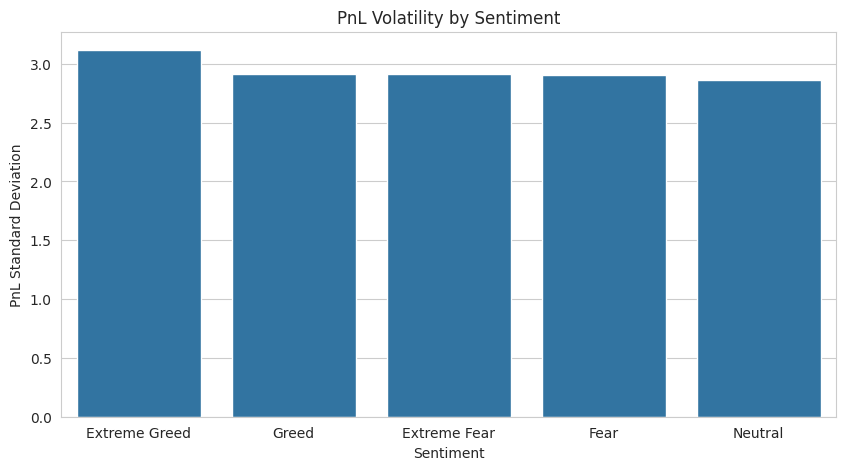

In [128]:
pnl_volatility = (
    merged_df
    .groupby('classification')['Closed PnL']
    .std()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=pnl_volatility.index,
    y=pnl_volatility.values
)

plt.title('PnL Volatility by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('PnL Standard Deviation')

plt.show()

In [131]:
trader_efficiency = (
    merged_df
    .groupby('Account')
    .agg({
        'Closed PnL': 'sum',
        'Trade ID': 'count'
    })
)

trader_efficiency.columns = [
    'total_pnl',
    'trade_count'
]

trader_efficiency['efficiency_score'] = (
    trader_efficiency['total_pnl'] /
    trader_efficiency['trade_count']
)

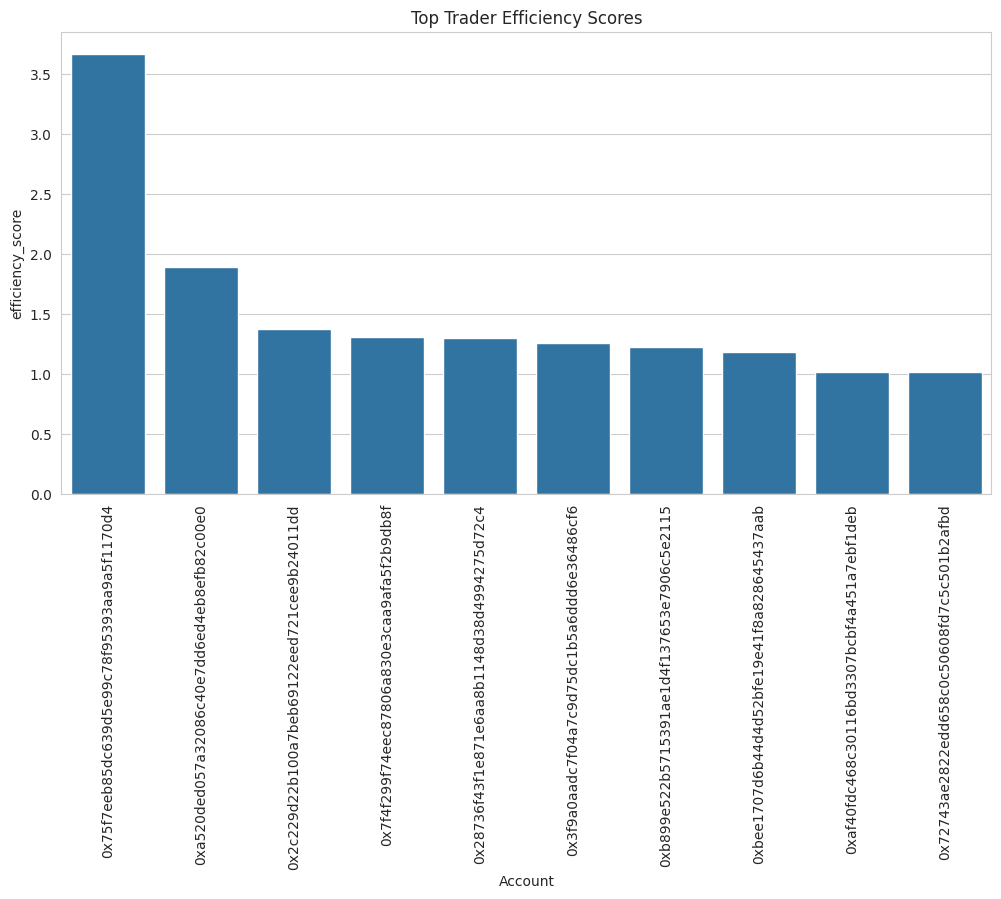

In [132]:
top_efficient = (
    trader_efficiency
    .sort_values(
        by='efficiency_score',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_efficient.index,
    y=top_efficient['efficiency_score']
)

plt.title('Top Trader Efficiency Scores')

plt.xticks(rotation=90)

plt.show()